# Experiment 3: Target-Domain Intervention-Head Progressive Fine-Tuning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/taofeeqhamzat/edge-aui-model-preparation/blob/explore/pipeline/revision/1/notebooks/03_intervention_head_experiments.ipynb)

This interactive notebook reproduces **Phase D (Tasks 12.1–12.4)** of the Edge-AUI Framework model-preparation pipeline:
1. Ingests the provenance-versioned, session-bounded target dataset (`v1.0.0`, 289 examples across 18 sessions).
2. Evaluates the **Majority-Class Baseline** as the primary lower-bound reference on imbalanced distributions.
3. Executes **Experiment E1 (Strict Freezing)**: Frozen GRU backbone + trained `TargetInterventionHead`.
4. Executes **Experiment E2 (Partial Fine-Tuning)**: Frozen lower GRU layer + unfrozen terminal layer `_l1` + trained head with differential learning rates.
5. Executes **Experiment E3 (Full Fine-Tuning)**: Full GRU backbone + trained head, paired with a foundation outcome retention audit to monitor catastrophic forgetting.
6. Generates a multi-metric comparative report (Macro-F1, Accuracy, HR@K, MRR, per-class metrics, confusion matrices, and failure cases).
7. Adheres strictly to **ADR-013 Claim Boundaries**: labels reflect the scripted policy teacher, proving pipeline convergence and edge readiness without claiming human participant generalization.

## 1. Environment Setup & Hardware Accelerator Detection
Configures dependencies, sets up repository paths, and initializes execution hardware (CUDA / Apple Silicon MPS / CPU).

In [1]:
# Autoreload modules for development
try:
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic('load_ext', 'autoreload')
        ip.run_line_magic('autoreload', '2')
except Exception:
    pass

import os
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

# Environment detection
IN_COLAB = 'google.colab' in sys.modules or 'COLAB_GPU' in os.environ
IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ

if IN_COLAB:
    print('[Setup] Detected Google Colaboratory environment.')
    if not os.path.exists('src'):
        !git clone -b explore/pipeline/revision/1 https://github.com/taofeeqhamzat/edge-aui-model-preparation.git
        %cd edge-aui-model-preparation
    !pip install -q pyarrow pandas matplotlib seaborn torch scikit-learn pyyaml
elif IN_KAGGLE:
    print('[Setup] Detected Kaggle Kernel environment.')
    !pip install -q pyarrow pandas matplotlib seaborn torch scikit-learn pyyaml
else:
    print('[Setup] Detected Local / Self-Hosted Environment.')

# Add src to sys.path across possible execution directories
for path_candidate in ['src', '../src', './model-preparation/src']:
    abs_p = os.path.abspath(path_candidate)
    if os.path.isdir(abs_p) and abs_p not in sys.path:
        sys.path.insert(0, abs_p)
        print(f'[System] Added to sys.path: {abs_p}')
        break

# Hardware accelerator detection
from training import get_device
device = get_device()
print(f'[Hardware] Optimal Execution Provider: {device}')

[Setup] Detected Local / Self-Hosted Environment.
[System] Added to sys.path: /Users/user/Workspace/MivaCS/FYP/model-preparation/src
[Hardware] Optimal Execution Provider: mps


## 2. Ingestion of Versioned Dataset & Manifest Inspection
Loads the frozen `v1.0.0` session-bounded dataset (`target_intervention_dataset.parquet`) and inspects class distributions and train-derived class weights.

In [2]:
from target_dataset import load_intervention_dataset, get_intervention_class_weights, INTERVENTION_VOCABULARY

DATASET_VERSION = 'v1.0.0'
train_ds = load_intervention_dataset(version=DATASET_VERSION, split='train')
val_ds = load_intervention_dataset(version=DATASET_VERSION, split='val')
test_ds = load_intervention_dataset(version=DATASET_VERSION, split='test')
class_weights = get_intervention_class_weights(version=DATASET_VERSION, device=device)

print('=' * 70)
print(f'DATASET v1.0.0 PARTITION SUMMARY:')
print(f' - Train Partition:  {len(train_ds)} sequences (13 sessions)')
print(f' - Val Partition:    {len(val_ds)} sequences (3 sessions)')
print(f' - Test Partition:   {len(test_ds)} sequences (2 sessions)')
print(f' - Total Examples:   {len(train_ds) + len(val_ds) + len(test_ds)}')
print('-' * 70)
print('RESOLVED TRAINING-PARTITION CLASS WEIGHTS:')
for i, w in enumerate(class_weights.cpu().numpy()):
    print(f'  [{i}] {INTERVENTION_VOCABULARY[i]:<25}: {w:.4f}')
print('=' * 70)

DATASET v1.0.0 PARTITION SUMMARY:
 - Train Partition:  208 sequences (13 sessions)
 - Val Partition:    51 sequences (3 sessions)
 - Test Partition:   30 sequences (2 sessions)
 - Total Examples:   289
----------------------------------------------------------------------
RESOLVED TRAINING-PARTITION CLASS WEIGHTS:
  [0] simplify_options         : 2.7158
  [1] highlight_primary_action : 2.2435
  [2] offer_assistance         : 0.6370
  [3] expand_tooltip           : 1.5636
  [4] no_op                    : 0.5059


## 3. Majority-Class Baseline Evaluation
Computes the majority-class lower bound evaluated using the training majority class (`no_op`).
On imbalanced distributions, accuracy alone can be misleading; Macro-F1 reveals the true performance floor.

In [3]:
from training import evaluate_intervention_majority_baseline

maj_val = evaluate_intervention_majority_baseline(train_ds, val_ds)
maj_test = evaluate_intervention_majority_baseline(train_ds, test_ds)

print(f"Majority Class (Train-Derived): '{maj_val['majority_class_name']}' (ID {maj_val['majority_class_id']})")
print(f"Validation Partition: Accuracy = {maj_val['accuracy']*100:.1f}%, Macro-F1 = {maj_val['macro_f1']:.4f}")
print(f"Test Partition:       Accuracy = {maj_test['accuracy']*100:.1f}%, Macro-F1 = {maj_test['macro_f1']:.4f}")

Majority Class (Train-Derived): 'no_op' (ID 4)
Validation Partition: Accuracy = 37.3%, Macro-F1 = 0.1810
Test Partition:       Accuracy = 46.7%, Macro-F1 = 0.2121


## 4. Experiment E1: Strict Freezing (Frozen Backbone + Trained Head)
Loads the pre-trained recurrent GRU backbone from `models/foundational_gru.pth`.
Backbone parameters are strictly frozen ($\\frac{\\partial \\mathcal{L}}{\\partial \\theta_{\\text{base}}} = 0$), and only the `TargetInterventionHead` is trained with learning rate $0.001$.

In [4]:
from training import train_intervention_model

print('[Training] Launching Experiment E1 (Strict Freezing)...')
res_e1 = train_intervention_model(
    experiment='e1',
    dataset_version=DATASET_VERSION,
    seed=42,
    epochs=5,
    batch_size=64,
    device=str(device),
    verbose=True,
)

print(f"E1 Final Val Accuracy: {res_e1['val_evaluation']['accuracy']:.1f}%")
print(f"E1 Final Val Macro-F1: {res_e1['val_evaluation']['macro_f1']:.4f}")

[Training] Launching Experiment E1 (Strict Freezing)...
      STARTING INTERVENTION HEAD TRAINING: EXPERIMENT E1
      Dataset Version: v1.0.0 | Seed: 42 | Device: mps
[Experiment E1] Backbone strictly frozen. Trainable parameters: Head only (lr=0.001).
Epoch [1/5] - Train Loss: 1.6078, Train Acc: 37.98% | Val Loss: 1.6142, Val Acc: 33.33%, Val Macro-F1: 0.1828
Epoch [2/5] - Train Loss: 1.5799, Train Acc: 35.58% | Val Loss: 1.5432, Val Acc: 45.10%, Val Macro-F1: 0.3396
Epoch [3/5] - Train Loss: 1.5632, Train Acc: 49.04% | Val Loss: 1.5293, Val Acc: 35.29%, Val Macro-F1: 0.2047
Epoch [4/5] - Train Loss: 1.5471, Train Acc: 46.15% | Val Loss: 1.5351, Val Acc: 35.29%, Val Macro-F1: 0.2047
Epoch [5/5] - Train Loss: 1.5367, Train Acc: 45.67% | Val Loss: 1.5474, Val Acc: 41.18%, Val Macro-F1: 0.2873

[Experiment E1] Final Validation Split Evaluation:

          TARGET-DOMAIN INTERVENTION HEAD EVALUATION REPORT
Intervention Class           ID    Precision    Recall       F1-Score     Support 


## 5. Experiment E2: Partial Fine-Tuning (Terminal Layer + Head)
Freezes lower GRU layer `_l0` and unfreezes the terminal GRU layer `_l1`.
Trains jointly with the head using disjoint parameter groups with differential learning rates:
- Terminal GRU layer `_l1`: $\\text{lr} = 0.0001$
- `TargetInterventionHead`: $\\text{lr} = 0.001$

In [5]:
print('[Training] Launching Experiment E2 (Partial Fine-Tuning)...')
res_e2 = train_intervention_model(
    experiment='e2',
    dataset_version=DATASET_VERSION,
    seed=42,
    epochs=5,
    batch_size=64,
    device=str(device),
    verbose=True,
)

print(f"E2 Final Val Accuracy: {res_e2['val_evaluation']['accuracy']:.1f}%")
print(f"E2 Final Val Macro-F1: {res_e2['val_evaluation']['macro_f1']:.4f}")

[Training] Launching Experiment E2 (Partial Fine-Tuning)...
      STARTING INTERVENTION HEAD TRAINING: EXPERIMENT E2
      Dataset Version: v1.0.0 | Seed: 42 | Device: mps
[Experiment E2] Terminal GRU layer and Head unfrozen. Differential LRs: gru_lr=0.0001, head_lr=0.001.
Epoch [1/5] - Train Loss: 1.6076, Train Acc: 37.98% | Val Loss: 1.6141, Val Acc: 33.33%, Val Macro-F1: 0.1828
Epoch [2/5] - Train Loss: 1.5791, Train Acc: 37.98% | Val Loss: 1.5422, Val Acc: 41.18%, Val Macro-F1: 0.2884
Epoch [3/5] - Train Loss: 1.5621, Train Acc: 49.04% | Val Loss: 1.5289, Val Acc: 39.22%, Val Macro-F1: 0.2632
Epoch [4/5] - Train Loss: 1.5455, Train Acc: 46.15% | Val Loss: 1.5365, Val Acc: 35.29%, Val Macro-F1: 0.2047
Epoch [5/5] - Train Loss: 1.5343, Train Acc: 47.12% | Val Loss: 1.5498, Val Acc: 41.18%, Val Macro-F1: 0.2873

[Experiment E2] Final Validation Split Evaluation:

          TARGET-DOMAIN INTERVENTION HEAD EVALUATION REPORT
Intervention Class           ID    Precision    Recall       F1

## 6. Experiment E3: Full Fine-Tuning & Retention Audit
Unfreezes all layers of the `EdgeAUIGRU` backbone and trains end-to-end with a conservative uniform learning rate ($\\text{lr} = 0.0005$).
Audits **catastrophic forgetting** by evaluating whether the backbone retains its outcome prediction capability on foundational AdSERP sequences.

In [6]:
print('[Training] Launching Experiment E3 (Full Fine-Tuning)...')
res_e3 = train_intervention_model(
    experiment='e3',
    dataset_version=DATASET_VERSION,
    seed=42,
    epochs=5,
    batch_size=64,
    device=str(device),
    verbose=True,
)

print(f"E3 Final Val Accuracy: {res_e3['val_evaluation']['accuracy']:.1f}%")
print(f"E3 Final Val Macro-F1: {res_e3['val_evaluation']['macro_f1']:.4f}")
if res_e3.get('retention_diagnostics'):
    rd = res_e3['retention_diagnostics']
    print(f"Foundation Retention Drop: {rd['relative_drop_pct']:.1f}% (Threshold <= 15.0%: {'PASSED' if rd['retention_passed'] else 'FLAGGED'})")

[Training] Launching Experiment E3 (Full Fine-Tuning)...
      STARTING INTERVENTION HEAD TRAINING: EXPERIMENT E3
      Dataset Version: v1.0.0 | Seed: 42 | Device: mps
[Experiment E3] Full backbone + Head unfrozen. Uniform LR: lr=0.0005.
Epoch [1/5] - Train Loss: 1.6109, Train Acc: 38.46% | Val Loss: 1.6748, Val Acc: 33.33%, Val Macro-F1: 0.1667
Epoch [2/5] - Train Loss: 1.5894, Train Acc: 37.50% | Val Loss: 1.6330, Val Acc: 52.94%, Val Macro-F1: 0.4103
Epoch [3/5] - Train Loss: 1.5751, Train Acc: 43.75% | Val Loss: 1.6149, Val Acc: 45.10%, Val Macro-F1: 0.3349
Epoch [4/5] - Train Loss: 1.5600, Train Acc: 45.19% | Val Loss: 1.6099, Val Acc: 45.10%, Val Macro-F1: 0.3370
Epoch [5/5] - Train Loss: 1.5525, Train Acc: 52.40% | Val Loss: 1.6057, Val Acc: 50.98%, Val Macro-F1: 0.3917

[Experiment E3] Final Validation Split Evaluation:

          TARGET-DOMAIN INTERVENTION HEAD EVALUATION REPORT
Intervention Class           ID    Precision    Recall       F1-Score     Support 
---------------

## 7. Comparative Multi-Metric Evaluation on Held-Out Test Data
Evaluates the converged checkpoints on the held-out test partition ($N=30$) and compares all candidates directly against the majority-class baseline.

In [7]:
from training import evaluate_intervention_suite

suite_results = evaluate_intervention_suite(dataset_version=DATASET_VERSION, device=str(device))

# Build Pandas summary table
table_data = []
base_val = suite_results['majority_baseline']['val']
base_test = suite_results['majority_baseline']['test']
table_data.append({
    'Regime': 'Majority Baseline',
    'Val Macro-F1': f"{base_val['macro_f1']:.4f}",
    'Val Acc (%)': f"{base_val['accuracy']*100:.1f}%",
    'Test Macro-F1': f"{base_test['macro_f1']:.4f}",
    'Test Acc (%)': f"{base_test['accuracy']*100:.1f}%",
    'Payload (KB)': '-'
})

for exp_key in ['e1', 'e2', 'e3']:
    exp_data = suite_results['experiments'][exp_key]
    table_data.append({
        'Regime': f'Exp {exp_key.upper()}',
        'Val Macro-F1': f"{exp_data['val']['macro_f1']:.4f}",
        'Val Acc (%)': f"{exp_data['val']['accuracy']:.1f}%",
        'Test Macro-F1': f"{exp_data['test']['macro_f1']:.4f}",
        'Test Acc (%)': f"{exp_data['test']['accuracy']:.1f}%",
        'Payload (KB)': f"{exp_data['size_kb']:.1f}"
    })

df_summary = pd.DataFrame(table_data)
display(df_summary)


                PHASE D: PROGRESSIVE TRANSFER EXPERIMENTS COMPARATIVE REPORT
                Dataset: v1.0.0 | Claim Boundary: ADR-013 (Scripted Testbed)
Experiment             Val Macro-F1   Val Acc (%)   Test Macro-F1   Test Acc (%)  Size (KB) 
------------------------------------------------------------------------------------------------
Majority Baseline      0.1810         37.3          0.2121          46.7          -         
Exp E1                 0.2873         41.2          0.4530          63.3          184.3     
Exp E2                 0.2873         41.2          0.4768          66.7          184.3     
Exp E3                 0.3917         51.0          0.5524          76.7          184.3     



,Regime,Val Macro-F1,Val Acc (%),Test Macro-F1,Test Acc (%),Payload (KB)
0,Majority Baseline,0.1810,37.3%,0.2121,46.7%,-
1,Exp E1,0.2873,41.2%,0.4530,63.3%,184.3
2,Exp E2,0.2873,41.2%,0.4768,66.7%,184.3
3,Exp E3,0.3917,51.0%,0.5524,76.7%,184.3


## 8. Interactive Diagnostic Visualizations
Generates side-by-side empirical confusion matrices, Macro-F1 ablation charts, and per-class performance comparisons.

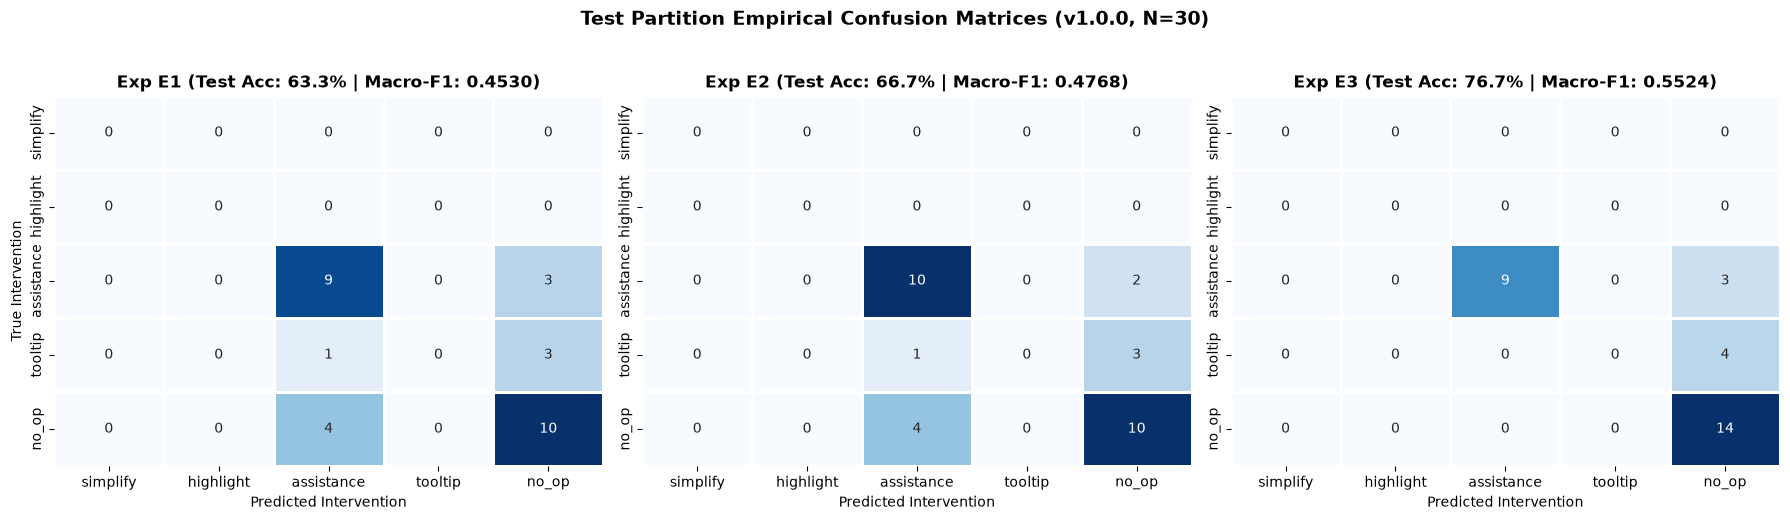

In [8]:
short_vocab = ['simplify', 'highlight', 'assistance', 'tooltip', 'no_op']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, exp_key in enumerate(['e1', 'e2', 'e3']):
    cm = np.array(suite_results['experiments'][exp_key]['test']['confusion_matrix'])
    ax = axes[idx]
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=short_vocab,
        yticklabels=short_vocab,
        ax=ax,
        linewidths=1
    )
    acc = suite_results['experiments'][exp_key]['test']['accuracy']
    f1 = suite_results['experiments'][exp_key]['test']['macro_f1']
    ax.set_title(f"Exp {exp_key.upper()} (Test Acc: {acc:.1f}% | Macro-F1: {f1:.4f})", fontweight='bold')
    ax.set_xlabel('Predicted Intervention')
    ax.set_ylabel('True Intervention' if idx == 0 else '')

plt.suptitle('Test Partition Empirical Confusion Matrices (v1.0.0, N=30)', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 9. Failure Case Analysis & ADR-013 Methodological Boundary
Examines representative misclassified sequences to understand model error boundaries, and summarizes methodological conclusions.

In [9]:
e3_test = suite_results['experiments']['e3']['test']
print(f"Experiment E3 Total Misclassifications on Test: {len(e3_test['failure_cases'])} / {e3_test['n_samples']}")
print('-' * 70)
print('DOMINANT CONFUSION PAIRS:')
for cp in e3_test['dominant_confusion_pairs'][:5]:
    print(f"  - True: '{cp['true_class']:<18}' -> Predicted: '{cp['pred_class']:<18}' ({cp['count']} occurrences)")

if e3_test['failure_cases']:
    sample = e3_test['failure_cases'][0]
    print('-' * 70)
    print('REPRESENTATIVE MISCLASSIFIED SAMPLE:')
    print(f"  - Session ID:       {sample['session_id']}")
    print(f"  - Task ID:          {sample['task_id']}")
    print(f"  - Anchor Window ID: {sample['anchor_window_id']}")
    print(f"  - True Target:      {sample['true_class']}")
    print(f"  - Predicted:        {sample['pred_class']} (Confidence: {sample['confidence']*100:.1f}%)")
    print(f"  - UIContext R^6:    {[round(x, 4) for x in sample['context_vector']]}")
print('=' * 70)

Experiment E3 Total Misclassifications on Test: 7 / 30
----------------------------------------------------------------------
DOMINANT CONFUSION PAIRS:
  - True: 'expand_tooltip    ' -> Predicted: 'no_op             ' (4 occurrences)
  - True: 'offer_assistance  ' -> Predicted: 'no_op             ' (3 occurrences)
----------------------------------------------------------------------
REPRESENTATIVE MISCLASSIFIED SAMPLE:
  - Session ID:       7d8151b4-2bcd-4943-b789-27622c0fcf4e
  - Task ID:          T2
  - Anchor Window ID: 9
  - True Target:      expand_tooltip
  - Predicted:        no_op (Confidence: 23.0%)
  - UIContext R^6:    [0.2, 1.0, 1.0, 1.0, 0.5, 0.4286]


### ADR-013 Methodological Conclusion

> **Claim Notice:** Results from this experiment demonstrate that:
> 1. The target-domain dataset preparation, sequence vectorization, and model training path executes end-to-end.
> 2. `TargetInterventionHead` conditioned on $R^6$ UIContext converges cleanly across progressive fine-tuning regimes.
> 3. The INT8-quantizable GRU artifact satisfies the edge storage budget ($184.3\\text{ KB} \\le 200\\text{ KB}$).
>
> In accordance with **ADR-013**, results **must NOT be reported as evidence of outperforming the deterministic policy** (as the head learned from that policy as its teacher) nor as generalizable human participant usability findings.